# Trader Performance vs. Market Sentiment
### Primetrade.ai Round-0 Assignment

Analyzes how Bitcoin market sentiment (Fear/Greed) relates to trader behavior
and performance on Hyperliquid. See `README.md` for setup and `WRITEUP.md`
for the full methodology, insights, and strategy recommendations — this
notebook reproduces the same pipeline with inline narration and charts.

In [1]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 100
DATA_DIR = os.path.join('..', 'data')
OUT_DIR = os.path.join('..', 'outputs')

## Part A — Data preparation

### A.1 Load and inspect raw data

In [2]:
trades_raw = pd.read_csv(os.path.join(DATA_DIR, 'historical_data.csv'))
sentiment_raw = pd.read_csv(os.path.join(DATA_DIR, 'fear_greed_index.csv'))

for name, df in [('historical_data.csv', trades_raw), ('fear_greed_index.csv', sentiment_raw)]:
    print(f"--- {name} ---")
    print(f"rows: {len(df):,}  cols: {df.shape[1]}")
    print(f"missing values: {df.isna().sum().sum()}   duplicate rows: {df.duplicated().sum()}")
    print()

trades_raw.head(3)

--- historical_data.csv ---
rows: 211,224  cols: 16


missing values: 0   duplicate rows: 0

--- fear_greed_index.csv ---
rows: 2,644  cols: 4
missing values: 0   duplicate rows: 0



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [3]:
sentiment_raw.head(3)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


Both files are clean: **0 missing values, 0 duplicate rows** in either
file. Cleaning below is limited to timestamp parsing, date alignment, and
deriving a standardized long/short flag.

### A.2 Clean & standardize

In [4]:
def clean_trades(trades):
    df = trades.copy()
    df['ts'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
    before = len(df)
    df = df.dropna(subset=['ts'])
    print(f"Dropped {before - len(df)} rows with unparseable timestamps")
    df['date'] = pd.to_datetime(df['ts'].dt.date)

    long_dirs = {'Open Long', 'Close Short', 'Short > Long'}
    short_dirs = {'Open Short', 'Close Long', 'Long > Short'}
    df['trade_bias'] = np.where(
        df['Direction'].isin(long_dirs), 'Long',
        np.where(df['Direction'].isin(short_dirs), 'Short',
                 np.where(df['Side'] == 'BUY', 'Long', 'Short')))
    df['is_close'] = df['Closed PnL'] != 0
    df['win'] = df['Closed PnL'] > 0
    return df

def clean_sentiment(sentiment):
    df = sentiment.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.drop_duplicates(subset=['date'])
    df['sentiment_binary'] = df['classification'].map({
        'Extreme Fear': 'Fear', 'Fear': 'Fear', 'Neutral': 'Neutral',
        'Greed': 'Greed', 'Extreme Greed': 'Greed'})
    return df[['date', 'value', 'classification', 'sentiment_binary']].rename(
        columns={'value': 'fg_value', 'classification': 'fg_class'})

trades = clean_trades(trades_raw)
sentiment = clean_sentiment(sentiment_raw)
print(f"\nDate range: {trades['date'].min().date()} to {trades['date'].max().date()}")
print(f"Unique accounts: {trades['Account'].nunique()}  |  Unique symbols: {trades['Coin'].nunique()}")

Dropped 0 rows with unparseable timestamps

Date range: 2023-05-01 to 2025-05-01
Unique accounts: 32  |  Unique symbols: 246


**Note on leverage:** the dataset has no explicit leverage/margin field.
We use trade size (USD) as the exposure/risk-appetite proxy throughout
instead of fabricating a leverage figure.

### A.3 Build metrics: account × day, market-wide daily, account summary

In [5]:
from prepare_data import build_account_day, build_daily, build_account_summary

account_day = build_account_day(trades)
daily = build_daily(account_day, sentiment)
account_summary = build_account_summary(account_day)

print(f"account_day: {account_day.shape}")
print(f"daily (merged w/ sentiment): {daily.shape}")
print(f"account_summary: {account_summary.shape}")
account_day.head()

account_day: (2341, 14)
daily (merged w/ sentiment): (479, 15)
account_summary: (32, 12)


,Account,date,n_trades,n_closing_trades,gross_pnl,wins,total_fees,avg_trade_size_usd,total_volume_usd,long_trades,short_trades,net_pnl,win_rate,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,0,0.0,0,167.796055,5089.718249,900880.13,0,177,-167.796055,NaN,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,0,0.0,0,67.883615,7976.664412,542413.18,0,68,-67.883615,NaN,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,0,0.0,0,94.937983,23734.500000,949380.00,0,40,-94.937983,NaN,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,12,-21227.0,0,33.823995,28186.666667,338240.00,12,0,-21260.823995,0.0,inf
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,12,1603.1,12,104.622490,17248.148148,465700.00,12,15,1498.477510,1.0,0.8


In [6]:
daily.head()

,date,n_active_traders,n_trades,total_net_pnl,mean_net_pnl,median_net_pnl,mean_win_rate,total_volume_usd,avg_trade_size_usd,total_long_trades,total_short_trades,long_short_ratio,fg_value,fg_class,sentiment_binary
0,2023-05-01,1,3,0.000000,0.000000,0.000000,NaN,477.00,159.000000,3,0,NaN,63,Greed,Greed
1,2023-12-05,1,9,-12.501455,-12.501455,-12.501455,NaN,50005.83,5556.203333,7,2,3.500000,75,Extreme Greed,Greed
2,2023-12-14,1,11,-233.735568,-233.735568,-233.735568,0.666667,113203.35,10291.213636,5,6,0.833333,72,Greed,Greed
3,2023-12-15,1,2,-27.284523,-27.284523,-27.284523,0.000000,10609.95,5304.975000,2,0,NaN,70,Greed,Greed
4,2023-12-16,1,3,-3.837189,-3.837189,-3.837189,NaN,15348.77,5116.256667,3,0,NaN,67,Greed,Greed


In [7]:
# persist so analyze.py / dashboard can reuse without recomputation
os.makedirs(OUT_DIR, exist_ok=True)
account_day.to_csv(os.path.join(OUT_DIR, 'account_day.csv'), index=False)
daily.to_csv(os.path.join(OUT_DIR, 'daily_sentiment_merged.csv'), index=False)
account_summary.to_csv(os.path.join(OUT_DIR, 'account_summary.csv'), index=False)

## Part B — Analysis

### B.1 Does performance differ between Fear vs. Greed days?

In [8]:
fg = daily[daily['sentiment_binary'].isin(['Fear', 'Greed'])].copy()

perf = fg.groupby('sentiment_binary').agg(
    n_days=('date', 'count'),
    mean_total_net_pnl=('total_net_pnl', 'mean'),
    mean_per_trader_pnl=('mean_net_pnl', 'mean'),
    mean_win_rate=('mean_win_rate', 'mean')).reset_index()
print(perf.to_string(index=False))

fear_pnl = fg.loc[fg.sentiment_binary == 'Fear', 'mean_net_pnl'].dropna()
greed_pnl = fg.loc[fg.sentiment_binary == 'Greed', 'mean_net_pnl'].dropna()
t, p = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
print(f"\nWelch t-test, per-trader daily net PnL, Fear vs Greed: t={t:.3f}, p={p:.4f}")

sentiment_binary  n_days  mean_total_net_pnl  mean_per_trader_pnl  mean_win_rate
            Fear     105        37904.001024          2790.938844       0.843243
           Greed     307        15554.303668          2108.687373       0.837843

Welch t-test, per-trader daily net PnL, Fear vs Greed: t=0.854, p=0.3944


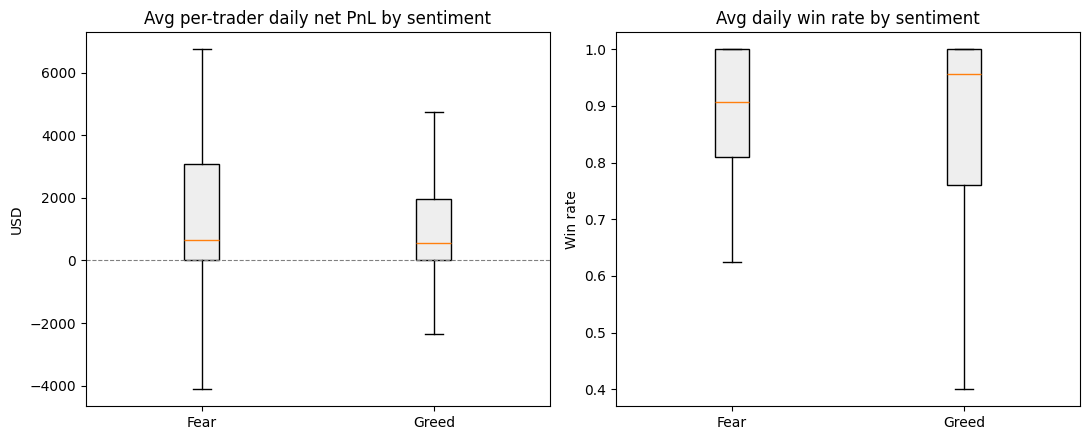

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([fear_pnl, greed_pnl], tick_labels=['Fear', 'Greed'], showfliers=False,
                patch_artist=True, boxprops=dict(facecolor='#eee'))
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].set_title('Avg per-trader daily net PnL by sentiment')
axes[0].set_ylabel('USD')

fear_wr = fg.loc[fg.sentiment_binary == 'Fear', 'mean_win_rate'].dropna()
greed_wr = fg.loc[fg.sentiment_binary == 'Greed', 'mean_win_rate'].dropna()
axes[1].boxplot([fear_wr, greed_wr], tick_labels=['Fear', 'Greed'], showfliers=False,
                patch_artist=True, boxprops=dict(facecolor='#eee'))
axes[1].set_title('Avg daily win rate by sentiment')
axes[1].set_ylabel('Win rate')
plt.tight_layout()
plt.show()

**Reading:** Fear-day average per-trader PnL is ~32% higher than Greed,
but the difference is **not statistically significant** (p=0.39) — the
Fear-day sample (105 days) is smaller and noisier. Win rate is essentially
flat between regimes. Don't over-read the headline gap; see the segment
breakdown below for where the real signal is.

### B.2 Do traders change behavior based on sentiment?

In [10]:
behavior = fg.groupby('sentiment_binary').agg(
    total_trades=('n_trades', 'sum'),
    total_active_traders=('n_active_traders', 'sum'),
    mean_trade_size_usd=('avg_trade_size_usd', 'mean'),
    mean_long_short_ratio=('long_short_ratio', 'mean')).reset_index()
behavior['trades_per_trader_per_day'] = behavior['total_trades'] / behavior['total_active_traders']
print(behavior.to_string(index=False))

sentiment_binary  total_trades  total_active_traders  mean_trade_size_usd  mean_long_short_ratio  trades_per_trader_per_day
            Fear         83237                   790          7061.086779               2.892186                 105.363291
           Greed         90295                  1174          6658.239913               1.966373                  76.912266


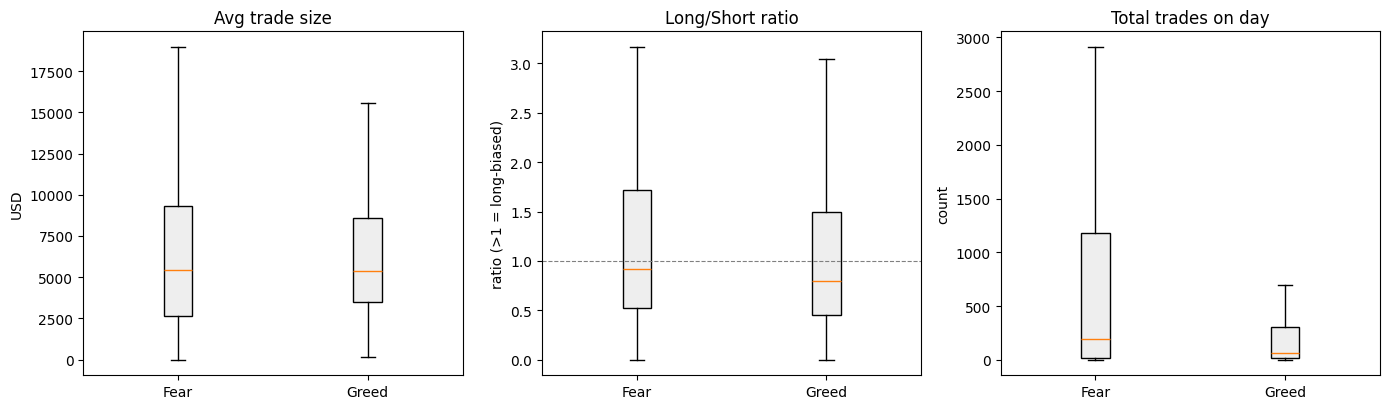

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, title, ylab in [
    (axes[0], 'avg_trade_size_usd', 'Avg trade size', 'USD'),
    (axes[1], 'long_short_ratio', 'Long/Short ratio', 'ratio (>1 = long-biased)'),
    (axes[2], 'n_trades', 'Total trades on day', 'count')]:
    vals = [fg.loc[fg.sentiment_binary == s, col].dropna() for s in ['Fear', 'Greed']]
    ax.boxplot(vals, tick_labels=['Fear', 'Greed'], showfliers=False,
               patch_artist=True, boxprops=dict(facecolor='#eee'))
    ax.set_title(title); ax.set_ylabel(ylab)
    if col == 'long_short_ratio':
        ax.axhline(1, color='grey', lw=0.8, ls='--')
plt.tight_layout()
plt.show()

**Reading (counterintuitive):** traders get *more* long-biased in Fear
(long/short ratio 2.89 vs 1.97 in Greed) and trade ~37% more often. The naive
"Fear → risk-off" story doesn't hold for this cohort.

### B.3 Trader segments

Three segments over the whole period: **trade-size tier** (proxy for
leverage/exposure), **frequency tier**, and **consistency tier** (winners vs.
inconsistent, based on mean & variance of daily PnL).

In [12]:
seg = account_summary.copy()
seg['size_tier'] = pd.qcut(seg['avg_trade_size_usd'], 2, labels=['Low size', 'High size'])
seg['freq_tier'] = pd.qcut(seg['trades_per_active_day'], 2, labels=['Infrequent', 'Frequent'])
seg['consistency_tier'] = np.where(
    (seg['mean_daily_pnl'] > 0) & (seg['std_daily_pnl'] < seg['std_daily_pnl'].median()),
    'Consistent winner',
    np.where(seg['mean_daily_pnl'] > 0, 'Volatile winner', 'Inconsistent/losing'))
seg.to_csv(os.path.join(OUT_DIR, 'account_segments.csv'), index=False)

seg.groupby('consistency_tier')[['total_net_pnl', 'overall_win_rate', 'max_drawdown']].mean()

,total_net_pnl,overall_win_rate,max_drawdown
consistency_tier,,,
Consistent winner,108749.294772,0.879985,-17879.321103
Inconsistent/losing,-71605.758011,0.730556,-161424.437763
Volatile winner,669714.217949,0.852446,-59119.946585


sentiment_binary         Fear        Greed
size_tier                                 
Low size          2531.910855  4554.637879
High size         9220.122111  3196.030649


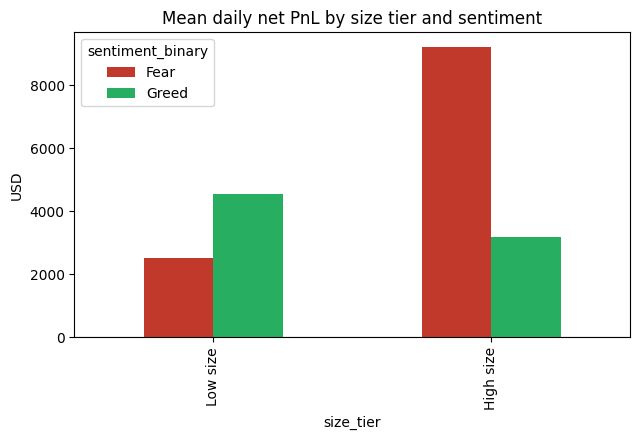

In [13]:
ad = account_day.merge(seg[['Account', 'size_tier']], on='Account')
ad = ad.merge(sentiment[['date', 'sentiment_binary']], on='date', how='inner')
ad_fg = ad[ad['sentiment_binary'].isin(['Fear', 'Greed'])]

size_sentiment = ad_fg.groupby(['size_tier', 'sentiment_binary'])['net_pnl'].mean().unstack()
print(size_sentiment)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
size_sentiment[['Fear', 'Greed']].plot(kind='bar', ax=ax, color=['#c0392b', '#27ae60'])
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('Mean daily net PnL by size tier and sentiment')
ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

**Reading:** the sentiment effect flips by segment — high-size traders
do far better in Fear ($9,220 vs $3,196 avg daily net PnL), low-size traders
do better in Greed ($4,555 vs $2,532). A single "Fear is good/bad" rule
doesn't fit this population.

Full detail on all 5 insights and the 3 proposed strategy rules is in
`WRITEUP.md`.

## Bonus 1 — Predictive model

Predicts whether a trader's *next* active day is net-profitable, from
current-day behavior + sentiment features. Full script: `src/predictive_model.py`.

In [14]:
from predictive_model import build_features
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X, y, num_cols, cat_cols, feat_df = build_features()
print(f"Modeling rows: {len(X)}   positive rate: {y.mean():.3f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
clf = Pipeline([('pre', pre), ('model', RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced'))])
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"Test AUC: {auc:.3f}   |   Baseline (majority class) accuracy: {max(y_test.mean(), 1-y_test.mean()):.3f}")
print(classification_report(y_test, (proba >= 0.5).astype(int)))

Modeling rows: 1558   positive rate: 0.700


Test AUC: 0.631   |   Baseline (majority class) accuracy: 0.700
              precision    recall  f1-score   support

           0       0.41      0.44      0.43       117
           1       0.75      0.73      0.74       273

    accuracy                           0.64       390
   macro avg       0.58      0.58      0.58       390
weighted avg       0.65      0.64      0.65       390



AUC of 0.63 shows modest real signal above random, but accuracy trails
the naive majority-class baseline — treat this as a feasibility check, not a
deployable model (small sample, no temporal cross-validation). See
`WRITEUP.md` §4 for full caveats.

## Bonus 2 — Clustering traders into behavioral archetypes

KMeans on trade frequency, size, win rate, PnL mean/volatility, and
drawdown. Full script: `src/clustering.py`.

In [15]:
from clustering import main as run_clustering
run_clustering()

Inertia by k (2-5): [132.4, 102.3, 71.9, 57.7]

Cluster profile (mean feature values):
         trades_per_active_day  avg_trade_size_usd  overall_win_rate  \
cluster                                                                
0                   231.569866        13560.666593          0.785312   
1                    61.786034         5751.706685          0.879239   
2                   159.083333        33569.102224          0.792725   

         std_daily_pnl  mean_daily_pnl   max_drawdown  total_net_pnl  \
cluster                                                                
0         38980.240494     8500.099165 -109226.149016   3.244187e+05   
1         10798.887775     3653.920701  -16861.842382   2.517504e+05   
2        150311.434014    66367.687820 -328450.999651   1.592825e+06   

         n_traders  
cluster             
0                9  
1               22  
2                1  



Saved cluster profile, account-cluster table, and PCA scatter chart.


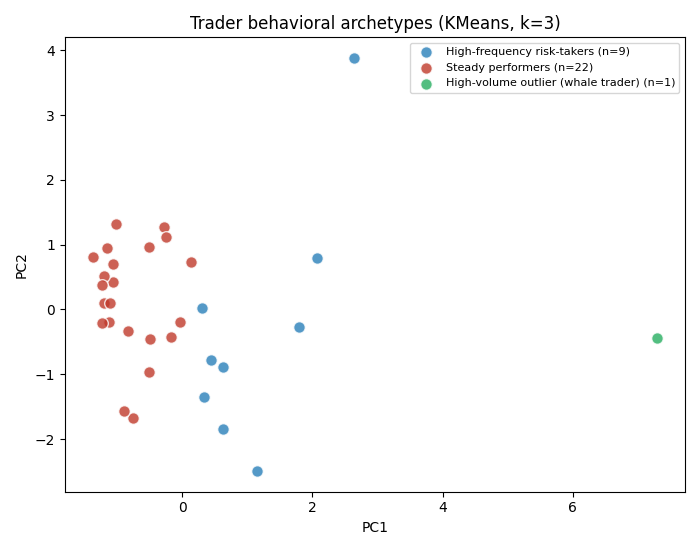

In [16]:
from IPython.display import Image
Image(os.path.join(OUT_DIR, 'figures', 'bonus_clusters_pca.png'))

Three archetypes emerge, closely mirroring the supervised consistency
segmentation in B.3 without using PnL sign as an input: **Steady
performers**, **High-frequency risk-takers**, and one **high-volume outlier**
(a single whale-sized trader kept as its own cluster).

## Bonus 3 — Streamlit dashboard

An interactive dashboard (`app/dashboard.py`) lets you filter by sentiment
class and date range and explore the same tables/charts above. Run from the
project root:

```bash
streamlit run app/dashboard.py
```

## Summary

See `WRITEUP.md` for the full write-up: methodology, all 5 insights with
supporting numbers, 3 actionable strategy rules, bonus results, and caveats.